In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy

# ── 1. Targets ────────────────────────────────────────────────────────────────
def target_function(X):
    return X[:,0]*X[:,1]*X[:,2]*X[:,3] + X[:,0]*X[:,1]*X[:,2] + X[:,0]*X[:,1] + X[:,0]

In [2]:
# ── 2. Data ───────────────────────────────────────────────────────────────────
torch.manual_seed(42)
d = 10
n_train = 1000

def make_data(n, target_fn):
    X = torch.randn(n, d)
    y = target_fn(X).unsqueeze(1)
    return X, y

In [3]:
# ── 3. Standard-param MLP (same init and lr for all widths) ───────────────────
class MLP(nn.Module):
    """
    Standard NTK-style init: W ~ N(0, 1/fan_in).
    No special scaling — width alone drives lazy vs rich.
    """
    def __init__(self, width, depth=3):
        super().__init__()
        layers = []
        in_dim = d
        for _ in range(depth - 1):
            layers += [nn.Linear(in_dim, width, bias=False), nn.ReLU()]
            in_dim = width
        self.feature_extractor = nn.Sequential(*layers)
        self.last_layer = nn.Linear(width, 1, bias=False)
        layers += [self.last_layer]
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                # standard init: std = 1/sqrt(fan_in)
                # this is the key — same for all widths
                nn.init.normal_(m.weight, std=1.0 / m.weight.shape[1] ** 0.5)

    def forward(self, x, return_features=False):
        if return_features:
            features = self.feature_extractor(x)
            output = self.last_layer(features) / (self.net[0].out_features ** 0.5)
            return output, features
        else:
            return self.net(x) / (self.net[0].out_features ** 0.5)

In [4]:
def metrics(model, X, y):
    y_pred, H = model(X, return_features=True)
    gram = H @ H.T
    inv_gram = torch.linalg.inv(H.T @ H + 0.01 * torch.eye(H.shape[1]))
    y_ols = torch.linalg.multi_dot([H, inv_gram, H.T, y])
    metric1 = (y - y_ols).norm().item()
    metric2 = (y_pred - y_ols).norm().item()
    metric3 = (y - y_pred).norm().item()
    return (metric1, metric2, metric3)

In [5]:
# ── 5. Training ───────────────────────────────────────────────────────────────
def train(model, X_tr, y_tr, lr=0.01, epochs=500):
    """
    Fixed lr for all widths — this is the point.
    As width grows, effective per-weight update shrinks → lazy.
    """
    opt     = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    metric_list = list()
    train_losses = []
    
    for ep in range(epochs):
        model.train()
        opt.zero_grad()
        loss_fn(model(X_tr), y_tr).backward()
        opt.step()

        if ep % 20 == 0:
            model.eval()
            with torch.no_grad():
                train_losses.append(loss_fn(model(X_tr), y_tr).item())
                metric_ret = metrics(model, X_tr, y_tr)
                metric_list.append(metric_ret)

    return train_losses, metric_list

In [27]:
# ── 6. Experiment ─────────────────────────────────────────────────────────────
# Narrow widths  → rich (features move)
# Wide widths    → lazy (stays near init / NTK)
widths  = [32, 128, 512, 1024]
lr      = 0.01
epochs  = 2000
results = {}   # (target, width) → (losses, laziness_ratio)

for target_name, target_fn in [('staircase', target_function)]:
    X_tr, y_tr = make_data(n_train, target_fn)

    for width in widths:
        model = MLP(width)
        losses, metrics_ret = train(model, X_tr, y_tr, lr=lr, epochs=epochs)
        results[(target_name, width)] = (losses, metrics_ret)
        print(f"{target_name:15s} | width={width:4d} "
              f"| final_test_loss={losses[-1]:.4f} ")

staircase       | width=  32 | final_test_loss=1.7425 
staircase       | width= 128 | final_test_loss=1.8251 
staircase       | width= 512 | final_test_loss=1.8943 
staircase       | width=1024 | final_test_loss=1.9428 


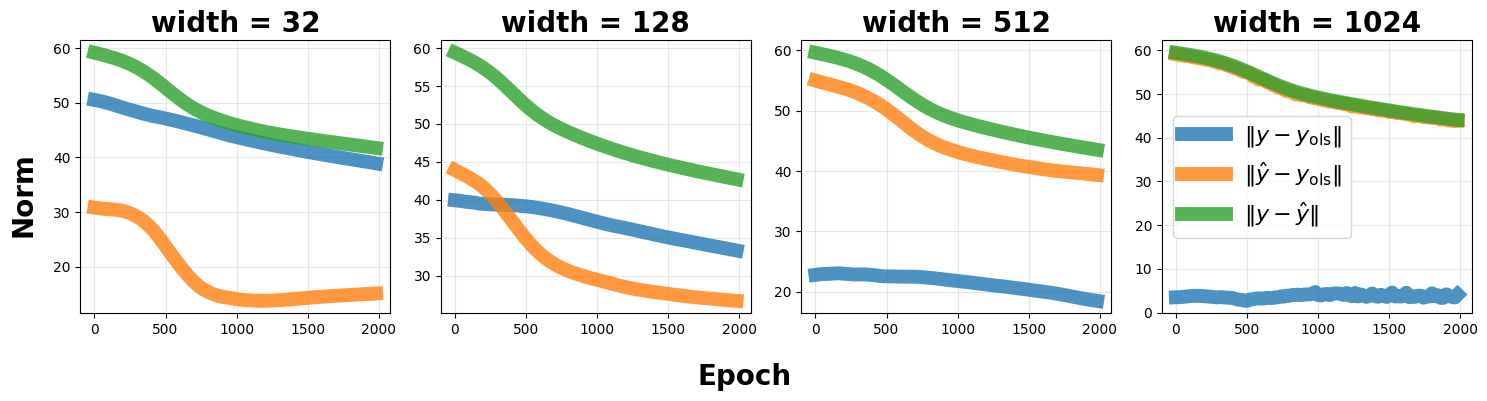

In [28]:

# ── 7. Visualization ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharex=True, sharey=False)

metric_names = [
    r'$\|y - y_{\mathrm{ols}}\|$',
    r'$\|\hat{y} - y_{\mathrm{ols}}\|$',
    r'$\|y - \hat{y}\|$',
]
colors = ['tab:blue', 'tab:orange', 'tab:green']

log_every = 20
x_axis = [ep * log_every for ep in range(len(results[('staircase', widths[0])][1]))]

for n, (ax, width) in enumerate(zip(axes, widths)):
    _, metric_list = results[('staircase', width)]
    m1, m2, m3 = zip(*metric_list)
    for vals, name, color in zip([m1, m2, m3], metric_names, colors):
        ax.plot(x_axis, vals, label=name, color=color, linewidth=10, alpha=0.8)
    ax.set_title(f'width = {width}', fontsize=20, fontweight='bold')
    if n == 3:
        ax.legend(fontsize=16)
    ax.grid(True, alpha=0.3)

fig.supxlabel('Epoch', fontsize=20, fontweight='bold')
fig.supylabel('Norm', fontsize=20, fontweight='bold', x=0.01)
plt.tight_layout()
plt.show()
